In [114]:
import string

import numpy as np
import pandas as pd
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy import stats
from pathlib import Path
from scipy.stats import kruskal, shapiro, f_oneway, ttest_ind
from matplotlib.patches import Patch, Rectangle
from matplotlib.legend_handler import HandlerBase
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

## Data Processing

In [115]:
df_MNIST_A = pd.read_csv('../GenRKM-MNIST/data/Attack-A-Results.csv')
df_MMCA_A = pd.read_csv('../GenRKM-MMCelebHQ-V3/data/Attack-A-Results.csv')
df_PS_A = pd.read_csv('../GenRKM-Poem/data/Attack-A-Results.csv')

df_MNIST_B = pd.read_csv('../GenRKM-MNIST/data/Attack-B-Results.csv')
df_MMCA_B = pd.read_csv('../GenRKM-MMCelebHQ-V3/data/Attack-B-Results.csv')
df_PS_B = pd.read_csv('../GenRKM-Poem/data/Attack-B-Results.csv')

In [116]:
df_MNIST_A_combined = df_MNIST_A.copy()
df_MMCA_A_combined = df_MMCA_A.copy()
# df_PS_A_combined = df_PS_A.copy()

# Add dataset labels
df_MNIST_A_combined['dataset'] = 'MNIST'
df_MMCA_A_combined['dataset'] = 'MMCA'
# df_PS_A_combined['dataset'] = 'PS'

# Use relative BIM increase for MNIST and PS
df_MNIST_A_combined['REL_ADV_Increase'] = (
    (df_MNIST_A_combined['BIM_IM_Loss'] - df_MNIST_A_combined['Clean_IM_Loss'])
    / df_MNIST_A_combined['Clean_IM_Loss']
) * 100

# df_PS_A_combined['REL_ADV_Increase'] = (
#     (df_PS_A_combined['ADV_TEXT_Loss'] - df_PS_A_combined['Clean_TEXT_Loss'])
#     / df_PS_A_combined['Clean_TEXT_Loss']
# ) * 100

# Use relative BIM image increase for MMCA
df_MMCA_A_combined['REL_ADV_Increase'] = (
    (df_MMCA_A_combined['BIM_IM_Loss'] - df_MMCA_A_combined['Clean_IM_Loss'])
    / df_MMCA_A_combined['Clean_IM_Loss']
) * 100

# Combine only the relevant columns
df_A = pd.concat(
    [
        df_MNIST_A_combined[['dataset', 'model', 'REL_ADV_Increase']],
        df_MMCA_A_combined[['dataset', 'model', 'REL_ADV_Increase']],
        # df_PS_A_combined[['dataset', 'model', 'REL_ADV_Increase']],
    ],
    ignore_index=True,
)

df_A

,dataset,model,REL_ADV_Increase
0,MNIST,1V,224.852667
1,MNIST,1V,210.807422
2,MNIST,1V,209.270618
3,MNIST,1V,213.940613
4,MNIST,1V,0.000000
...,...,...,...
95,MMCA,1V,552.503817
96,MMCA,1V,558.395491
97,MMCA,1V,553.233117
98,MMCA,1V,523.267703


In [117]:
df_mean_A = (
    df_A
    .mean(numeric_only=True)
    .to_frame()
    .T
    .round(2)
)

df_mean_A

,REL_ADV_Increase
0,496.13


In [118]:
df_MNIST_B_combined = df_MNIST_B.copy()
df_MMCA_B_combined = df_MMCA_B.copy()
# df_PS_B_combined = df_PS_B.copy()

# Add dataset labels
df_MNIST_B_combined['dataset'] = 'MNIST'
df_MMCA_B_combined['dataset'] = 'MMCA'
# df_PS_B_combined['dataset'] = 'PS'

# Use relative BIM increase for MNIST and PS
df_MNIST_B_combined['REL_ADV_Increase'] = (
    (df_MNIST_B_combined['BIM_IM_Loss'] - df_MNIST_B_combined['Clean_IM_Loss'])
    / df_MNIST_B_combined['Clean_IM_Loss']
) * 100

# df_PS_B_combined['REL_ADV_Increase'] = (
#     (df_PS_B_combined['ADV_TEXT_Loss'] - df_PS_B_combined['Clean_TEXT_Loss'])
#     / df_PS_B_combined['Clean_TEXT_Loss']
# ) * 100

# Use relative BIM image increase for MMCA
df_MMCA_B_combined['REL_ADV_Increase'] = (
    (df_MMCA_B_combined['BIM_IM_Loss'] - df_MMCA_B_combined['Clean_IM_Loss'])
    / df_MMCA_B_combined['Clean_IM_Loss']
) * 100

# Combine only the relevant columns
df_B = pd.concat(
    [
        df_MNIST_B_combined[['dataset', 'model', 'REL_ADV_Increase']],
        df_MMCA_B_combined[['dataset', 'model', 'REL_ADV_Increase']],
        # df_PS_B_combined[['dataset', 'model', 'REL_ADV_Increase']],
    ],
    ignore_index=True,
)

df_B

,dataset,model,REL_ADV_Increase
0,MNIST,1V,1091.431496
1,MNIST,1V,1228.927485
2,MNIST,1V,890.628816
3,MNIST,1V,1003.441361
4,MNIST,1V,976.694555
...,...,...,...
145,MMCA,3V,617.325571
146,MMCA,3V,559.137196
147,MMCA,3V,755.378721
148,MMCA,3V,265.261496


In [119]:
df_mean_B = (
    df_B
    .mean(numeric_only=True)
    .to_frame()
    .T
    .round(2)
)

df_mean_B

,REL_ADV_Increase
0,667.53


In [120]:
df_AB = pd.concat([df_A, df_B], ignore_index=True).replace({
    '2V-IS': '2V',
    '2V-IL': '2V',
})

df_AB

,dataset,model,REL_ADV_Increase
0,MNIST,1V,224.852667
1,MNIST,1V,210.807422
2,MNIST,1V,209.270618
3,MNIST,1V,213.940613
4,MNIST,1V,0.000000
...,...,...,...
245,MMCA,3V,617.325571
246,MMCA,3V,559.137196
247,MMCA,3V,755.378721
248,MMCA,3V,265.261496


In [121]:
df_mean_dataset = (
    df_AB
    .groupby('dataset', as_index=False)
    .mean(numeric_only=True)
    .round(2)
)

df_mean_dataset

,dataset,REL_ADV_Increase
0,MMCA,590.34
1,MNIST,633.48


In [122]:
df_mean_model = (
    df_AB
    .groupby('model', as_index=False)
    .mean(numeric_only=True)
    .round(2)
)

df_mean_model

,model,REL_ADV_Increase
0,1V,578.47
1,2V,500.29
2,3V,820.25


## Statistical Tests
### Normality - Attack

In [123]:
test_cols = [
    'REL_ADV_Increase',
]

In [124]:
normality_results = []

for col in test_cols:
    print(f'\n===== {col} =====')

    for df_name, df_data in [('df_A', df_A), ('df_B', df_B)]:
        values = (
            df_data[col]
            .dropna()
            .to_numpy()
        )

        w_stat, p_value = shapiro(values)

        normality_results.append({
            'dataframe': df_name,
            'metric': col,
            'W': w_stat,
            'p': p_value,
            'normal': p_value > 0.05,
        })

        print(f'{df_name}: W = {w_stat:.4f}, p = {p_value:.4f}')

normality_df = pd.DataFrame(normality_results)

normality_df


===== REL_ADV_Increase =====
df_A: W = 0.9058, p = 0.0000
df_B: W = 0.9460, p = 0.0000


,dataframe,metric,W,p,normal
0,df_A,REL_ADV_Increase,0.905822,0.000003,False
1,df_B,REL_ADV_Increase,0.945965,0.000015,False


In [125]:
ttest_results = []

for col in test_cols:
    values_A = df_A[col].dropna().to_numpy()
    values_B = df_B[col].dropna().to_numpy()

    t_stat, p_value = ttest_ind(
        values_A,
        values_B,
        equal_var=False,  # Welch's unpaired t-test
    )

    ttest_results.append({
        'metric': col,
        't-statistic': t_stat,
        'p-value': p_value,
        'significant': p_value < 0.05,
    })

ttest_df = pd.DataFrame(ttest_results)

ttest_df

,metric,t-statistic,p-value,significant
0,REL_ADV_Increase,-3.347407,0.000957,True


### Multi-View

In [126]:
test_rows = [
    '1V',
    '2V',
    '3V'
]

test_col = 'REL_ADV_Increase'

In [127]:
normality_results = []

print(f'\n===== {test_col} =====')

for model in test_rows:
    values = (
        df_AB.loc[df_AB['model'].eq(model), test_col]
        .dropna()
        .to_numpy()
    )

    w_stat, p_value = shapiro(values)

    normality_results.append({
        'model': model,
        'metric': test_col,
        'W': w_stat,
        'p': p_value,
        'normal': p_value > 0.05,
    })

    print(f'{model}: W = {w_stat:.4f}, p = {p_value:.4f}')

normality_df = pd.DataFrame(normality_results)

normality_df


===== REL_ADV_Increase =====
1V: W = 0.9187, p = 0.0002
2V: W = 0.9177, p = 0.0000
3V: W = 0.7515, p = 0.0000


,model,metric,W,p,normal
0,1V,REL_ADV_Increase,0.918742,2.320876e-04,False
1,2V,REL_ADV_Increase,0.917669,1.767585e-06,False
2,3V,REL_ADV_Increase,0.751515,1.005094e-08,False


In [128]:
groups = [
    df_AB.loc[df_AB['model'].eq(model), test_col]
    .dropna()
    .to_numpy()
    for model in test_rows
]

h_stat, p_value = kruskal(*groups)

kruskal_results = pd.DataFrame({
    'test': ['Kruskal-Wallis'],
    'metric': [test_col],
    'groups': [', '.join(test_rows)],
    'H-statistic': [h_stat],
    'p-value': [p_value],
    'significant': [p_value < 0.05],
})

kruskal_results

,test,metric,groups,H-statistic,p-value,significant
0,Kruskal-Wallis,REL_ADV_Increase,"1V, 2V, 3V",25.101941,0.000004,True


In [129]:

def tukey_letter_display(data, value_col, group_col='model', group_order=None, alpha=0.05):
    if group_order is None:
        group_order = sorted(data[group_col].dropna().unique())

    tukey = pairwise_tukeyhsd(
        endog=data[value_col],
        groups=data[group_col],
        alpha=alpha,
    )

    tukey_df = pd.DataFrame(
        tukey._results_table.data[1:],
        columns=tukey._results_table.data[0],
    )

    reject_df = pd.DataFrame(
        False,
        index=group_order,
        columns=group_order,
    )

    for _, row in tukey_df.iterrows():
        g1 = row['group1']
        g2 = row['group2']
        reject = bool(row['reject'])

        reject_df.loc[g1, g2] = reject
        reject_df.loc[g2, g1] = reject

    means = (
        data
        .groupby(group_col)[value_col]
        .mean()
        .loc[group_order]
        .sort_values()
    )

    letters = {group: '' for group in means.index}
    available_letters = list(string.ascii_lowercase)

    for group in means.index:
        for letter in available_letters:
            groups_with_letter = [
                other_group
                for other_group, assigned_letters in letters.items()
                if letter in assigned_letters
            ]

            can_share_letter = all(
                not reject_df.loc[group, other_group]
                for other_group in groups_with_letter
            )

            if can_share_letter:
                letters[group] += letter
                break

        if letters[group] == '':
            new_letter = available_letters[
                max(
                    [available_letters.index(l) for ls in letters.values() for l in ls],
                    default=-1,
                ) + 1
            ]
            letters[group] += new_letter

    letter_df = pd.DataFrame({
        group_col: group_order,
        'mean': data.groupby(group_col)[value_col].mean().loc[group_order].values,
        'letters': [letters[group] for group in group_order],
    })

    return tukey, tukey_df, letter_df

In [130]:
for col in test_cols:
    print(f'\n===== {col} =====')

    tukey, tukey_df, letter_df = tukey_letter_display(
        df_AB,
        value_col=col,
        group_col='model',
        group_order=test_rows,
        alpha=0.05,
    )
    
    display(letter_df)


===== REL_ADV_Increase =====


,model,mean,letters
0,1V,578.467893,a
1,2V,500.287737,a
2,3V,820.248945,b


### Disentanglement

In [131]:
test_rows = [
    'MNIST',
    'MMCA',
]

group_col = 'dataset'
test_col = 'REL_ADV_Increase'

In [132]:
values_1 = (
    df_AB.loc[df_AB[group_col].eq(test_rows[0]), test_col]
    .dropna()
    .to_numpy()
)

values_2 = (
    df_AB.loc[df_AB[group_col].eq(test_rows[1]), test_col]
    .dropna()
    .to_numpy()
)

t_stat, p_value = ttest_ind(
    values_1,
    values_2,
    equal_var=False,  # Welch's unpaired t-test
)

ttest_results = pd.DataFrame({
    'test': ["Welch's unpaired t-test"],
    'comparison': [f'{test_rows[0]} vs {test_rows[1]}'],
    'metric': [test_col],
    't-statistic': [t_stat],
    'p-value': [p_value],
    'significant': [p_value < 0.05],
})

ttest_results

,test,comparison,metric,t-statistic,p-value,significant
0,Welch's unpaired t-test,MNIST vs MMCA,REL_ADV_Increase,0.585075,0.560494,False


## Plots

/var/folders/yd/xmg755ln3fscr3pf2_0xpclm0000gn/T/ipykernel_18401/1782219311.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


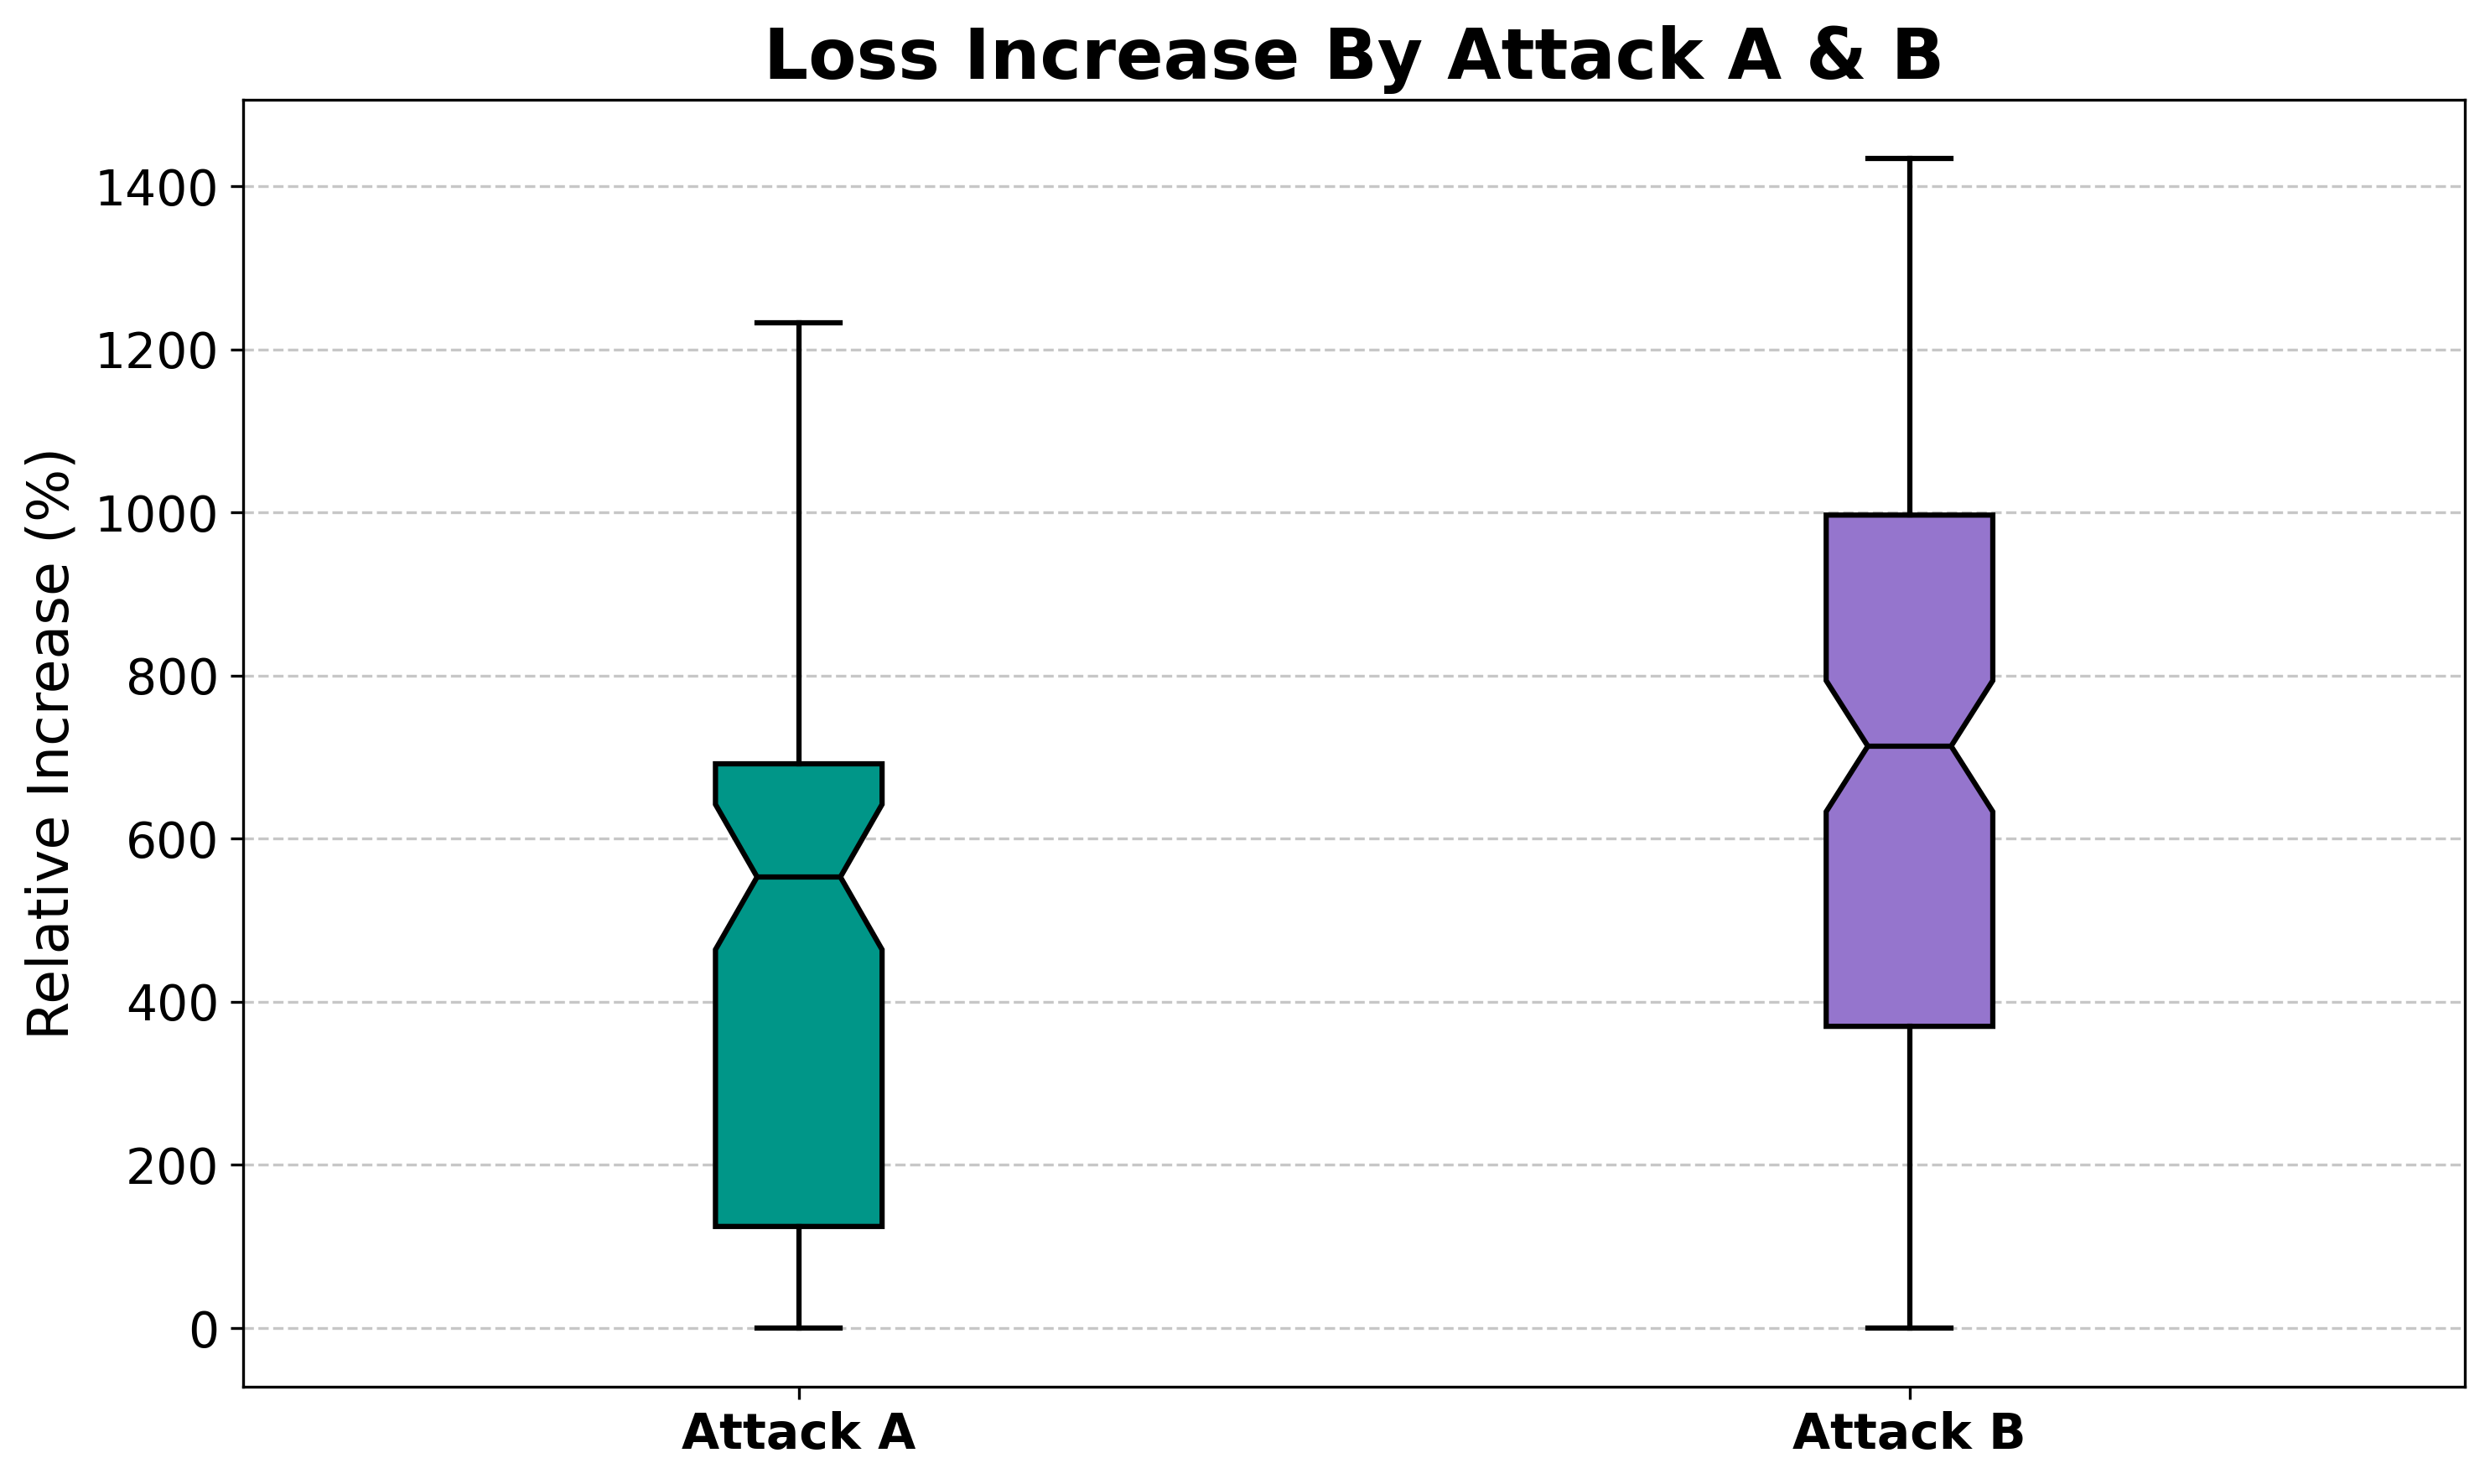

In [133]:
plot_col = 'REL_ADV_Increase'

colors = ['#009688','#9575CD','#BFBFBF']

plot_df = pd.concat(
    [
        df_A[[plot_col]].assign(dataframe='A'),
        df_B[[plot_col]].assign(dataframe='B'),
    ],
    ignore_index=True,
).dropna(subset=[plot_col])

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

box = ax.boxplot(
    [
        plot_df.loc[plot_df['dataframe'].eq('A'), plot_col],
        plot_df.loc[plot_df['dataframe'].eq('B'), plot_col],
    ],
    labels=['Attack A', 'Attack B'],
    patch_artist=True,
    showfliers=True,
    notch=True,
)

for patch, color in zip(box['boxes'], colors[:2]):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

for whisker in box['whiskers']:
    whisker.set_color('black')
    whisker.set_linewidth(1.5)

for cap in box['caps']:
    cap.set_color('black')
    cap.set_linewidth(1.5)

for median in box['medians']:
    median.set_color('black')
    median.set_linewidth(1.5)

for flier in box['fliers']:
    flier.set_marker('o')
    flier.set_markerfacecolor('white')
    flier.set_markeredgecolor('black')
    flier.set_markersize(5)

ax.set_ylabel('Relative Increase (%)', fontsize=16)
ax.set_title('Loss Increase By Attack A & B', fontsize=20, fontweight='bold')

ax.tick_params(axis='both', labelsize=14)

for tick in ax.get_xticklabels():
    tick.set_fontweight('bold')

ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('./img/relative_adv_increase_boxplot.png', dpi=300)
plt.show()

/var/folders/yd/xmg755ln3fscr3pf2_0xpclm0000gn/T/ipykernel_18401/262032819.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


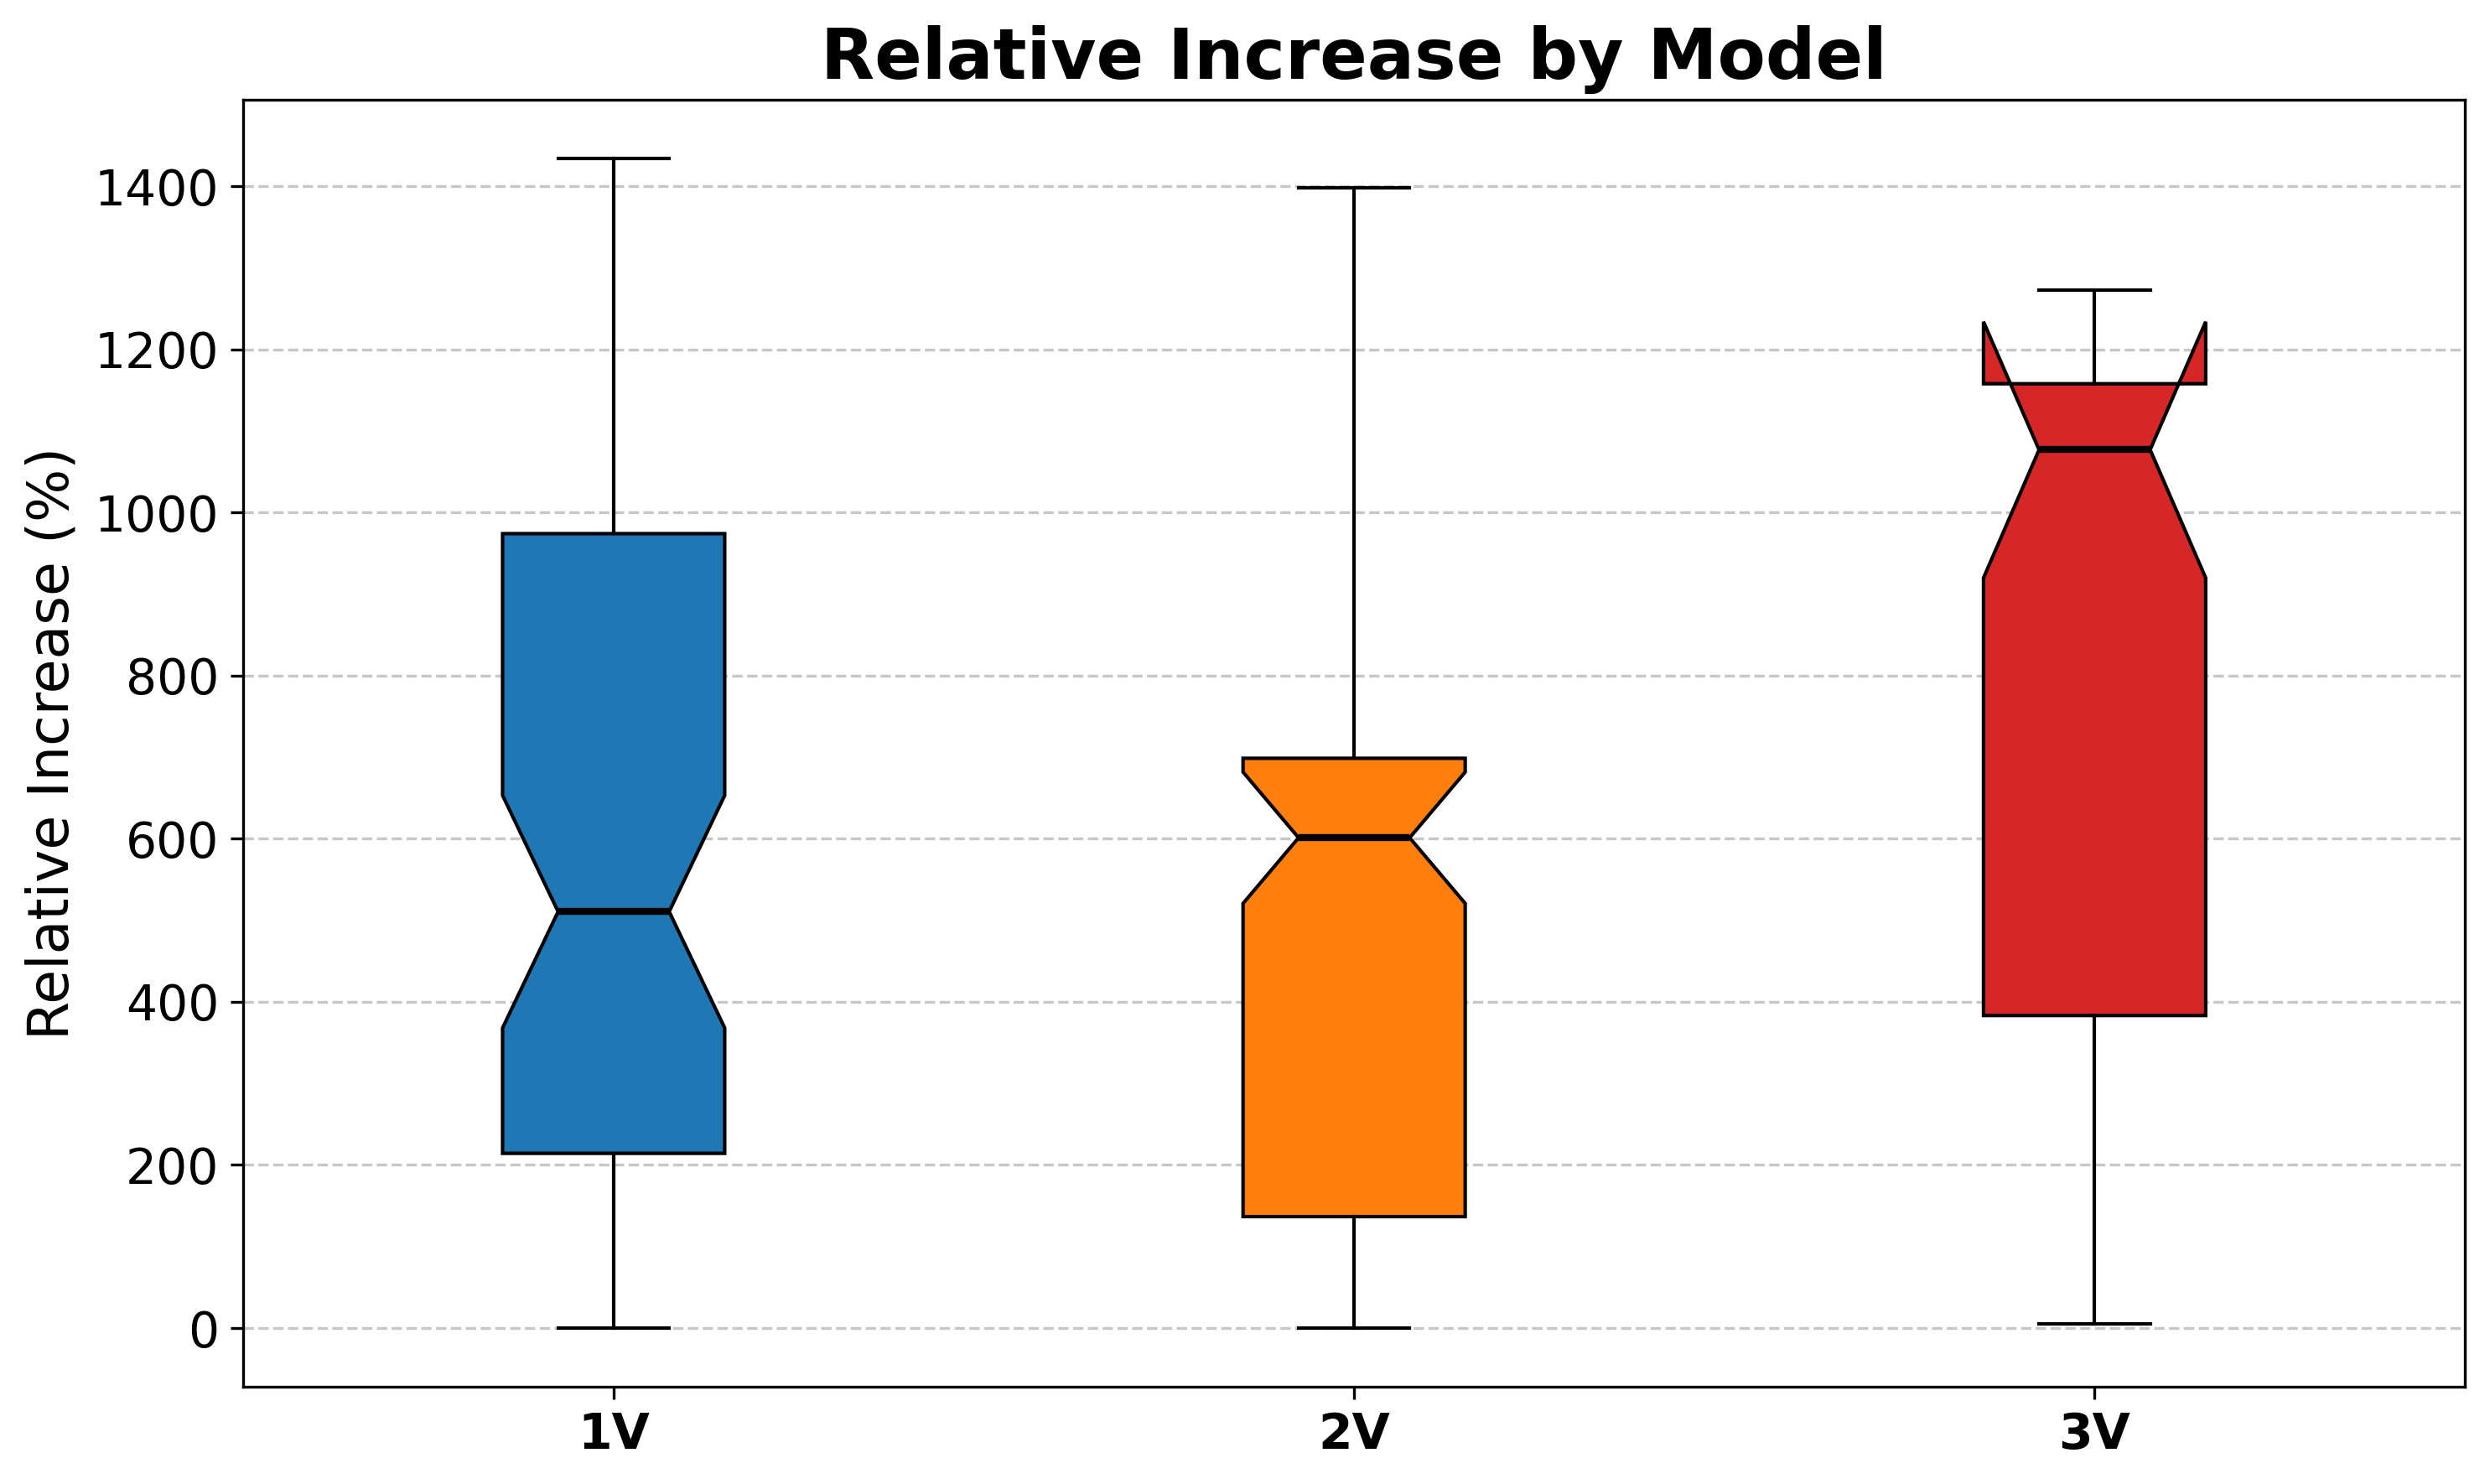

In [134]:
import matplotlib.pyplot as plt

test_rows = ['1V', '2V', '3V']
test_col = 'REL_ADV_Increase'

df_AB['model_grouped'] = df_AB['model'].apply(
    lambda x: '2V' if str(x).startswith('2V') else x
)

plot_df = df_AB.loc[df_AB['model_grouped'].isin(test_rows)].copy()

values = [
    plot_df.loc[plot_df['model_grouped'].eq(model), test_col].dropna().to_numpy()
    for model in test_rows
]

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

box = ax.boxplot(
    values,
    labels=test_rows,
    patch_artist=True,
    showfliers=True,
    notch=True,
)

colors = [
    'tab:blue',
    'tab:orange',
    'tab:red',
]

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(1)

for median in box['medians']:
    median.set_color('black')
    median.set_linewidth(2)

ax.set_ylabel('Relative Increase (%)', fontsize=16)
ax.set_title('Relative Increase by Model', fontsize=20, fontweight='bold')

ax.tick_params(axis='both', labelsize=14)

for tick in ax.get_xticklabels():
    tick.set_fontweight('bold')

ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('./img/relative_adv_increase_by_views_boxplot.png', dpi=300)
plt.show()

/var/folders/yd/xmg755ln3fscr3pf2_0xpclm0000gn/T/ipykernel_18401/3611760831.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


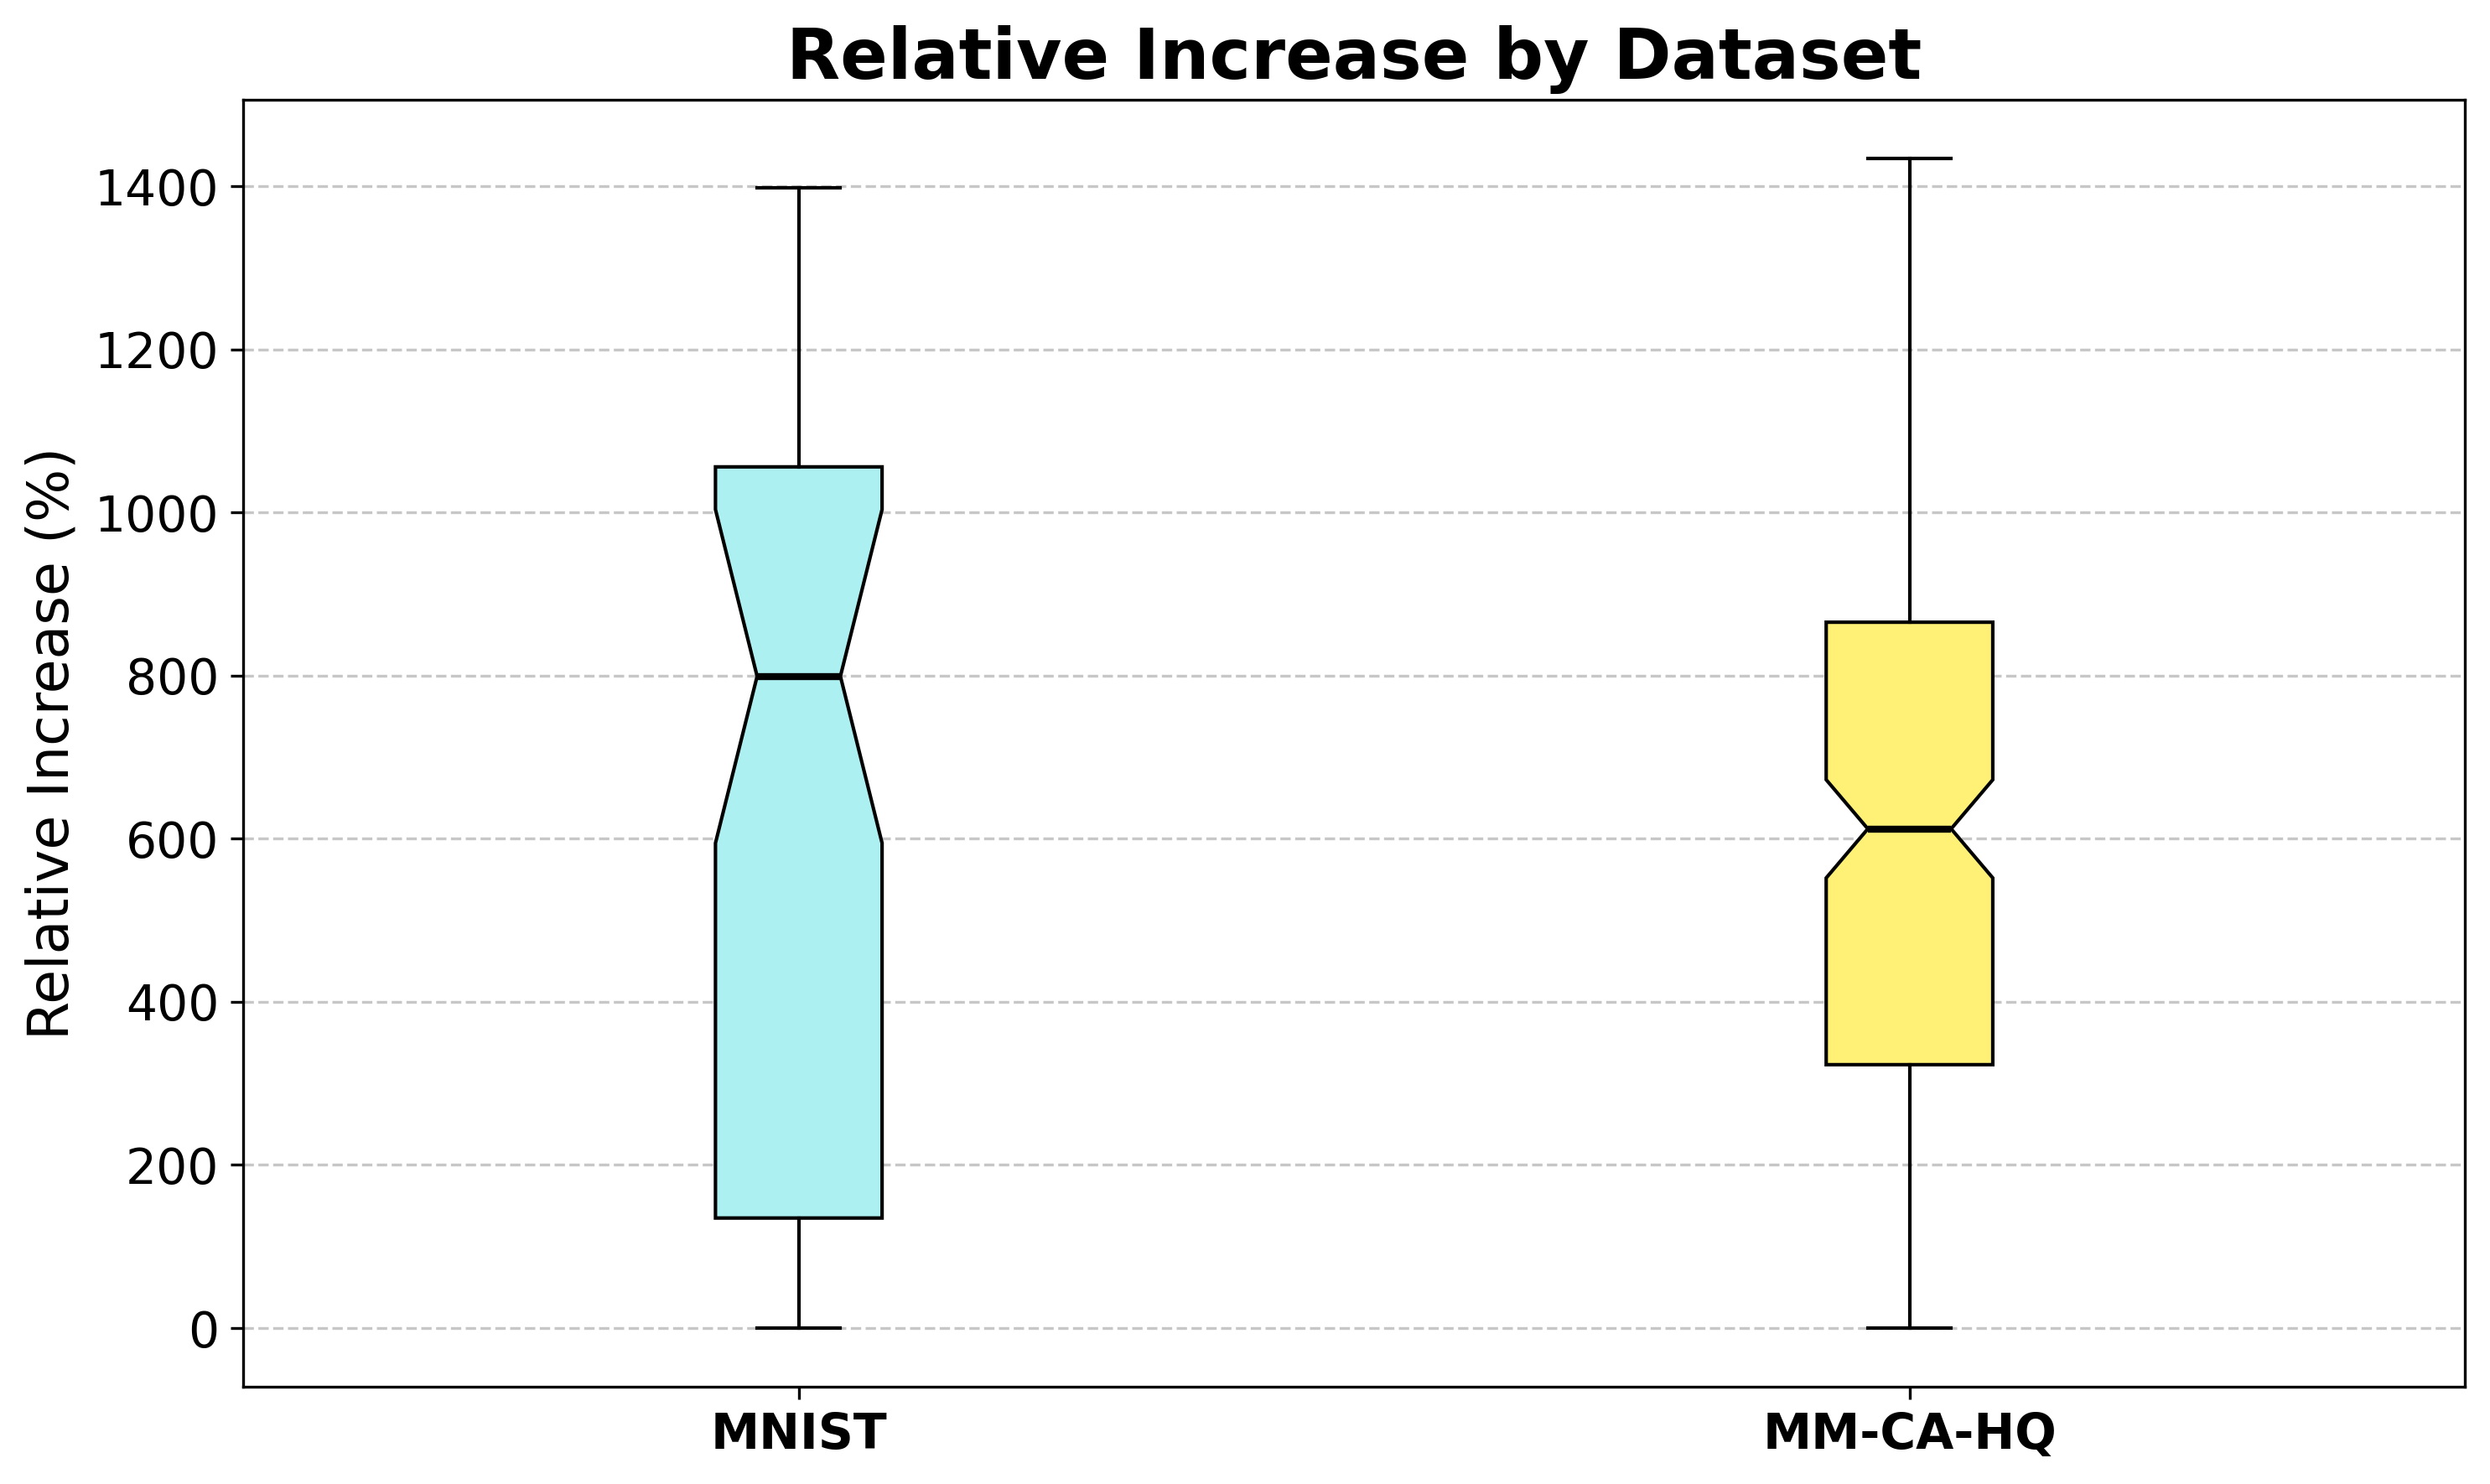

In [135]:
test_rows = [
    'MNIST',
    'MMCA',
]

group_col = 'dataset'
test_col = 'REL_ADV_Increase'

plot_df = df_AB.loc[df_AB[group_col].isin(test_rows)].copy()

values = [
    plot_df.loc[plot_df[group_col].eq(dataset), test_col].dropna().to_numpy()
    for dataset in test_rows
]

colors = [
    '#ACF0F2',
    '#FFF176',
]

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

box = ax.boxplot(
    values,
    labels=['MNIST', 'MM-CA-HQ'],
    patch_artist=True,
    showfliers=True,
    notch=True,
)

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(1)

for median in box['medians']:
    median.set_color('black')
    median.set_linewidth(2)

ax.set_ylabel('Relative Increase (%)', fontsize=16)
ax.set_title('Relative Increase by Dataset', fontsize=20, fontweight='bold')

ax.tick_params(axis='both', labelsize=14)

for tick in ax.get_xticklabels():
    tick.set_fontweight('bold')

ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('./img/relative_adv_increase_by_dataset_boxplot.png', dpi=300)
plt.show()